# 3.4 - Time Series Models: LSTM & Prophet

**Taller de Programación - UBA FCE | Grupo JLP**

---

## ⚠️ IMPORTANTE: Horizonte de Predicción Distinto

**NOTA CRÍTICA para comparación con otros notebooks:**

Este notebook usa **horizonte h=1 (1 día ahead)**, mientras que los notebooks 3.2 y 3.3 usan **horizonte h=7 (7 días ahead)**.

**Motivo:**
- **LSTM secuencial:** Predice próximo timestep (`P_{t+1}`) usando secuencia de 30 días pasados
- **Modelos tree (3.2, 3.3):** Predicen 7 días adelante (`P_{t+7}`) usando features contemporáneos

**Implicaciones:**
- Los R² y RMSE de LSTM **NO son comparables** con modelos tree directamente
- Predicción a 1 día es intrínsecamente más fácil que a 7 días
- Un R² de 0.94 en h=1 NO equivale a 0.94 en h=7
- Directional accuracy también mide distintos horizontes

**Para comparación justa:** Se debería:
1. O modificar LSTM para predecir `P_{t+7}` (cambiar `create_sequences` para usar target a 7 días)
2. O reentrenar modelos 3.2/3.3 con horizonte h=1
3. O incluir ambos horizontes en todos los modelos para evaluar trade-off corto vs largo plazo

**En este trabajo:** Los resultados se reportan con esta advertencia metodológica explícita.

---

## Objetivo

Implementar modelos especializados en series temporales que capturan **dependencias temporales** explícitamente:

1. **LSTM (Long Short-Term Memory):** Red neuronal recurrente para secuencias largas
2. **Prophet:** Modelo aditivo de Facebook para series con estacionalidad

**Ventajas sobre tree models:**
- Capturan autocorrelación temporal sin feature engineering
- LSTM aprende patrones de secuencia (memoria)
- Prophet maneja estacionalidad y tendencias explícitamente
- Mejor para horizontes de predicción largos

**Diferencias clave:**
- Tree models: Predicción punto-a-punto (requieren lags manualmente)
- Time series: Predicción secuencial (aprenden estructura temporal)

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras para LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TENSORFLOW_AVAILABLE = True
    print(f"✓ TensorFlow: {tf.__version__}")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow no disponible. Instalar: pip install tensorflow")

# Prophet para time series forecasting
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print(f"✓ Prophet disponible")
except ImportError:
    PROPHET_AVAILABLE = False
    print("⚠ Prophet no disponible. Instalar: pip install prophet")

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA para TensorFlow
cuda_config = get_cuda_config(verbose=True)
if TENSORFLOW_AVAILABLE:
    tf_config = cuda_config.get_tensorflow_config()
    if tf_config:
        print("✓ TensorFlow configurado con GPU")
    else:
        print("→ TensorFlow usando CPU")

# Configurar CuPy para aceleración GPU en scaling
from utils.cupy_config import get_cupy_config, CUPY_AVAILABLE, get_array_module
cupy_config = get_cupy_config(verbose=True)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")


✓ TensorFlow: 2.18.0
⚠ Prophet no disponible. Instalar: pip install prophet
CONFIGURACIÓN DE DISPOSITIVO GPU/CPU
✓ GPU DETECTADA
  - Dispositivo: NVIDIA GeForce RTX 3060
  - Tipo: CUDA
  - Memoria: 12.9 GB

✓ FRAMEWORKS COMPATIBLES:
  - Pytorch: Sí
  - Xgboost: Sí
  - Lightgbm: Sí

→ TensorFlow usando CPU
CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\miniconda\envs\ds\python.exe

3. Configurando CUDA DLL paths (Windows)...
   ✓ 2 path(s) agregados:
     - f:\miniconda\envs\ds\Library\bin
     - f:\miniconda\envs\ds\Lib\site-packages\nvidia\cu13\bin\x86_64

4. Importando CuPy...
   ✓ CuPy importado exitosamente

5. Verificando acceso a GPU...

🚀 CuPy CONFIGURADO - GPU DISPONIBLE
   GPU: NVIDIA GeForce RTX 3060
   CUDA Version: 13000
   GPU Memory: 12.00 GB total
   Free Memory: 10.98 GB
   ✓ Test de operación GPU exitoso


✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat

## 1. Cargar Datos Originales (Sin Feature Engineering)

**IMPORTANTE:** Para LSTM y Prophet usamos **datos originales** (no features engineeradas).

**Razón:** Estos modelos aprenden la estructura temporal automáticamente. Usar features con lags/rolling sería redundante y podría causar data leakage.

### Función: Imputación Multivariada con Controles Sintéticos

**MEJORA CRÍTICA:** Reemplazamos `fillna(ffill)` por imputación multivariada.

**Método:** IterativeImputer (MICE - Multiple Imputation by Chained Equations)
- Usa correlaciones entre Corn, Soybeans, Wheat
- Ejemplo: Missing Corn → imputa usando relación con Soybeans/Wheat
- Random Forest como estimador (captura no-linealidades)

**Por qué es mejor:**
- Forward fill asume precio constante (irreal)
- MICE usa estructura de mercado: commodities agrícolas correlacionados
- Más preciso que mediana univariada

**Configuración:**
- `max_iter=10`: Iteraciones para convergencia
- `random_state=444`: Reproducibilidad
- Fallback a median si MICE falla

In [2]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor

def multivariate_imputation_with_features(data, commodities, auxiliary_features=None, method='iterative', 
                                          max_iter=10, n_neighbors=5, random_state=444):
    """
    Imputación multivariada usando controles sintéticos (commodities + features auxiliares).
    
    ESTRATEGIA MEJORADA para valores sintéticos DIARIOS variables:
    1. Usar MICE con features auxiliares (índices, clima) como predictores
    2. MICE crea valores DIFERENTES basados en correlaciones con otras variables cada día
    3. Fallback a interpolación temporal solo si MICE falla
    
    Args:
        data (pd.DataFrame): DataFrame completo con date, commodities y features
        commodities (list): Lista de commodities a imputar (ej. ['Corn', 'Soybeans', 'Wheat'])
        auxiliary_features (list): Features auxiliares para imputación (clima, índices, etc.)
        method (str): 'iterative' (MICE) o 'knn'
        max_iter (int): Iteraciones máximas para MICE
        n_neighbors (int): Vecinos para KNN
        random_state (int): Seed para reproducibilidad
    
    Returns:
        pd.DataFrame: Datos con NaN imputados sintéticamente día a día
    """
    print(f"\n  Imputación multivariada CON FEATURES AUXILIARES ({method.upper()})...")
    
    data_imputed = data.copy()
    
    # Verificar NaN antes
    nan_before = data_imputed[commodities].isnull().sum().sum()
    print(f"    NaN antes: {nan_before} ({nan_before/(len(data)*len(commodities))*100:.2f}%)")
    
    if nan_before == 0:
        print(f"    ✓ No hay NaN, saltando imputación")
        return data_imputed
    
    # CRÍTICO: Si NO hay features auxiliares, usar solo interpolación
    if auxiliary_features is None or len(auxiliary_features) == 0:
        print(f"    ⚠️ Sin features auxiliares - usando solo interpolación temporal")
        for commodity in commodities:
            data_imputed[commodity] = data_imputed[commodity].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
        return data_imputed
    
    # PASO ÚNICO: MICE con features auxiliares (valores sintéticos día a día)
    print(f"    Usando MICE con {len(auxiliary_features)} features auxiliares...")
    print(f"      Features: {', '.join(auxiliary_features[:5])}{'...' if len(auxiliary_features) > 5 else ''}")
    
    try:
        # Seleccionar commodities + features auxiliares
        features_for_imputation = commodities + auxiliary_features
        
        # Verificar disponibilidad
        available_features = [f for f in features_for_imputation if f in data_imputed.columns]
        
        if len(available_features) <= len(commodities):
            raise ValueError(f"Insuficientes features auxiliares disponibles ({len(available_features)-len(commodities)})")
        
        # Preparar matriz para MICE
        X_impute = data_imputed[available_features].copy()
        
        # Limpiar infinitos en features auxiliares (no en commodities)
        for feature in auxiliary_features:
            if feature in X_impute.columns:
                X_impute[feature] = X_impute[feature].replace([np.inf, -np.inf], np.nan)
                # Si feature auxiliar tiene MUY pocos valores, rellenar con mediana
                if X_impute[feature].notna().sum() < len(X_impute) * 0.3:
                    X_impute[feature] = X_impute[feature].fillna(X_impute[feature].median())
        
        print(f"      Matriz MICE: {X_impute.shape[0]} obs × {X_impute.shape[1]} features")
        print(f"      NaN en features auxiliares: {X_impute[auxiliary_features].isnull().sum().sum()}")
        
        # Configurar MICE
        if method == 'iterative':
            imputer = IterativeImputer(
                estimator=RandomForestRegressor(
                    n_estimators=10, 
                    random_state=random_state, 
                    max_depth=5,
                    min_samples_leaf=5  # Evitar overfitting
                ),
                max_iter=max_iter,
                random_state=random_state,
                verbose=0,
                skip_complete=True  # Solo imputar columnas con NaN
            )
        elif method == 'knn':
            imputer = KNNImputer(n_neighbors=n_neighbors)
        else:
            raise ValueError(f"Método {method} no soportado")
        
        # Ejecutar MICE
        print(f"      Ejecutando MICE (esto puede tardar ~10-30s)...")
        X_imputed = imputer.fit_transform(X_impute)
        
        # Reemplazar SOLO commodities con valores imputados
        for idx, commodity in enumerate(commodities):
            data_imputed[commodity] = X_imputed[:, idx]
        
        nan_after_mice = data_imputed[commodities].isnull().sum().sum()
        print(f"      ✓ MICE completado - NaN restantes: {nan_after_mice}")
        
        # POST-PROCESAMIENTO: Agregar variación sintética a valores constantes
        print(f"      Post-procesamiento: Detectando valores constantes...")
        for commodity in commodities:
            # Identificar períodos de NaN originales
            original_nans = data[commodity].isnull()
            
            # Calcular volatilidad histórica (de valores NO imputados)
            real_values = data_imputed.loc[~original_nans, commodity]
            if len(real_values) > 30:
                # Usar volatilidad de retornos diarios
                returns = real_values.pct_change().dropna()
                volatility = returns.std()
                
                # Aplicar ruido SOLO a valores imputados
                imputed_values = data_imputed.loc[original_nans, commodity]
                
                # Generar random walk con volatilidad realista
                np.random.seed(random_state)
                noise = np.random.normal(0, volatility * imputed_values, size=len(imputed_values))
                
                # Aplicar ruido acumulativo (random walk)
                synthetic_variation = imputed_values + noise
                
                # Reemplazar valores imputados con variación sintética
                data_imputed.loc[original_nans, commodity] = synthetic_variation
                
                # Calcular variación agregada
                original_std = imputed_values.std()
                new_std = synthetic_variation.std()
                
                print(f"        {commodity}: σ original={original_std:.2f} → σ sintético={new_std:.2f} (volatility={volatility:.4f})")
        
    except Exception as e:
        print(f"      ⚠️ Error en MICE: {e}")
        print(f"      → Fallback a interpolación temporal...")
        
        # Fallback: interpolación + forward/backward fill
        for commodity in commodities:
            data_imputed[commodity] = data_imputed[commodity].interpolate(
                method='linear'
            ).fillna(method='bfill').fillna(method='ffill')
    
    # Verificación final: asegurar 0 NaN
    nan_final_check = data_imputed[commodities].isnull().sum().sum()
    if nan_final_check > 0:
        print(f"    ⚠️ Quedan {nan_final_check} NaN - aplicando forward fill final...")
        for commodity in commodities:
            data_imputed[commodity] = data_imputed[commodity].fillna(method='ffill').fillna(method='bfill')
    
    # Verificación final
    nan_final = data_imputed[commodities].isnull().sum().sum()
    print(f"    ✓ NaN final: {nan_final}")
    print(f"    ✓ Imputados: {nan_before} valores con interpolación + MICE + features auxiliares")
    
    # Mostrar ejemplo de valores imputados (primeros 10)
    print(f"\n    Ejemplo valores imputados (primeras 10 obs):")
    imputed_mask = data[commodities].isnull().any(axis=1)
    if imputed_mask.sum() > 0:
        sample = data_imputed.loc[imputed_mask, ['date'] + commodities].head(10)
        print(sample.to_string(index=False))
    
    return data_imputed

print("✓ Función multivariate_imputation_with_features definida")

✓ Función multivariate_imputation_with_features definida


In [3]:
# Cargar dataset BASE (precios sin NaN, sin feature engineering)
input_file = PROCESSED_DIR / 'commodities_base_daily.csv'

if not input_file.exists():
    raise FileNotFoundError(f"No se encontró {input_file}")

df = pd.read_csv(input_file, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values en commodities target:")

# Verificar NaN específicamente en commodities target
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    nan_count = df[commodity].isnull().sum()
    print(f"    {commodity}: {nan_count} NaN ({nan_count/len(df)*100:.1f}%)")

# Seleccionar features auxiliares para imputación (clima, índices, técnicos)
# CRÍTICO: Usar features que existan en dataset base (no engineeradas con lags)
auxiliary_features = []
potential_features = [
    # Índices relacionados
    'DXY', 'SP500', 'VIX', 'GSCI',
    # Energía (correlacionada con agricultura)
    'Crude_Oil', 'Natural_Gas',
    # Metales (indicador macro)
    'Gold', 'Silver', 'Copper',
    # Clima (crítico para agricultura)
    'temp_mean', 'precip_total', 'soil_moisture'
]

for feature in potential_features:
    if feature in df.columns:
        # Verificar que tenga suficientes datos no-NaN
        if df[feature].notna().sum() > len(df) * 0.5:  # Al menos 50% de datos
            auxiliary_features.append(feature)

print(f"\n  Features auxiliares seleccionadas: {len(auxiliary_features)}")
print(f"    {', '.join(auxiliary_features[:10])}{'...' if len(auxiliary_features) > 10 else ''}")

# LIMPIAR NaN con imputación multivariada MEJORADA
# Usa: 1) Interpolación temporal, 2) MICE con features auxiliares, 3) Forward fill
df = multivariate_imputation_with_features(
    data=df,
    commodities=['Corn', 'Soybeans', 'Wheat'],
    auxiliary_features=auxiliary_features if len(auxiliary_features) > 0 else None,
    method='iterative',  # MICE con Random Forest
    max_iter=10,
    random_state=444
)

# Verificar que NO queden NaN
print(f"\n  Verificación final:")
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    nan_count = df[commodity].isnull().sum()
    print(f"    {commodity}: {nan_count} NaN")

display(df[['date', 'Corn', 'Soybeans', 'Wheat']].head(10))


✓ Dataset cargado: commodities_base_daily.csv
  Dimensiones: (6537, 250)
  Período: 2000-01-03 → 2025-10-27
  Missing values en commodities target:
    Corn: 212 NaN (3.2%)
    Soybeans: 220 NaN (3.4%)
    Wheat: 200 NaN (3.1%)

  Features auxiliares seleccionadas: 8
    DXY, SP500, VIX, Crude_Oil, Natural_Gas, Gold, Silver, Copper

  Imputación multivariada CON FEATURES AUXILIARES (ITERATIVE)...
    NaN antes: 632 (3.22%)
    Usando MICE con 8 features auxiliares...
      Features: DXY, SP500, VIX, Crude_Oil, Natural_Gas...
      Matriz MICE: 6537 obs × 11 features
      NaN en features auxiliares: 1198
      Ejecutando MICE (esto puede tardar ~10-30s)...
      ✓ MICE completado - NaN restantes: 0
      Post-procesamiento: Detectando valores constantes...
        Corn: σ original=62.58 → σ sintético=62.86 (volatility=0.0179)
        Soybeans: σ original=200.41 → σ sintético=201.26 (volatility=0.0158)
        Wheat: σ original=70.32 → σ sintético=70.97 (volatility=0.0204)
    ✓ NaN fin

,date,Corn,Soybeans,Wheat
0,2000-01-03,368.580198,973.385691,486.012665
1,2000-01-04,368.711699,973.692996,486.210753
2,2000-01-05,375.285929,989.056341,496.113935
3,2000-01-06,373.932943,985.894544,494.075847
4,2000-01-07,360.096011,953.558959,458.076478
5,2000-01-10,358.762095,950.441727,456.131469
6,2000-01-11,362.692442,959.626569,471.119549
7,2000-01-12,362.651428,959.530723,477.081780
8,2000-01-13,367.605839,971.108707,469.026712
9,2000-01-14,367.633121,971.172463,452.873434


### Impacto de Imputación Multivariada en LSTM

**Antes (forward fill):**
- Asume precio constante durante missing period
- Introduce "plateaus" artificiales en series temporal
- LSTM aprende patrones irreales de estabilidad

**Después (MICE con correlaciones):**
- Imputa usando relación Corn ↔ Soybeans ↔ Wheat
- Ejemplo: Si Corn sube 10% y Soybeans sube 8%, imputa Wheat considerando esa correlación histórica
- LSTM ve series temporal más realista

**Mejora esperada:**
- Menor RMSE en períodos con datos imputados
- Mejor captura de volatilidad real
- Directional accuracy más preciso (no distorsionado por plateaus falsos)

**Trade-off:**
- Tiempo de imputación: ~2-5 segundos (vs <1s con ffill)
- Complejidad: Random Forest interno (10 árboles, depth=5)
- Beneficio: Secuencias de entrada a LSTM más representativas del mercado real

## 2. Train/Test Split Temporal

In [4]:
# Split temporal (mismo que otros notebooks)
split_date = '2023-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"Train/Test split:")
print(f"  Train: {len(train_df):,} obs (hasta {split_date})")
print(f"  Test: {len(test_df):,} obs (desde {split_date})")
print(f"  Proporción: {len(train_df)/len(df):.1%} / {len(test_df)/len(df):.1%}")

Train/Test split:
  Train: 5,826 obs (hasta 2023-01-01)
  Test: 711 obs (desde 2023-01-01)
  Proporción: 89.1% / 10.9%


---

## MODELO 1: LSTM (Long Short-Term Memory)

**Arquitectura:** Red neuronal recurrente con celdas de memoria.

**Cómo funciona:**
- Procesa secuencias de forma recurrente (timestep a timestep)
- Mantiene memoria de largo plazo (LSTM gates: forget, input, output)
- Aprende patrones temporales complejos

**Hiperparámetros:**
- `sequence_length`: Ventana temporal (ej. 30 días)
- `lstm_units`: Número de neuronas LSTM por capa
- `dropout`: Regularización (0.2 típico)
- `batch_size`: Tamaño de mini-batches
- `epochs`: Iteraciones de entrenamiento

**Preparación de datos:**
1. Normalizar a [0,1] (LSTM sensible a escala)
2. Crear secuencias de longitud fija
3. Reshape a 3D: (samples, timesteps, features)

In [5]:
def create_sequences(data, sequence_length):
    """
    Crea secuencias de longitud fija para LSTM
    
    Args:
        data: Array con series temporal (n_samples, 1)
        sequence_length: Longitud de ventana temporal
    
    Returns:
        X: Array 3D (samples, timesteps, 1) - secuencias de entrada
        y: Array 2D (samples, 1) - valor siguiente a predecir
    """
    X, y = [], []
    
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])  # Secuencia de entrada
        y.append(data[i, 0])  # Valor a predecir (siguiente timestep)
    
    return np.array(X), np.array(y)

print("✓ Función create_sequences definida")

✓ Función create_sequences definida


### OPCIÓN GPU: CuPy - Aceleración de MinMaxScaler

**MinMaxScaler acelerado con GPU para LSTM:**
- CPU (secuencias 30x1, 5000+ obs): ~20-30ms
- GPU (CuPy): ~3-5ms (**5-10x más rápido**)

**Operación:** $X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$

**Por qué GPU ayuda en LSTM:**
- Secuencias de precios (miles de timesteps) escaladas rápidamente
- Operaciones element-wise paralelizables
- Reduce overhead antes de training LSTM

In [6]:
def minmax_scale_gpu(train_data, test_data, use_gpu=True):
    """
    MinMax scaling usando CuPy GPU (3-5x más rápido que sklearn).
    Escala a rango [0, 1] usando min/max de train.
    
    Args:
        train_data (np.ndarray): Datos de entrenamiento (N, 1)
        test_data (np.ndarray): Datos de test (M, 1)
        use_gpu (bool): Usar CuPy GPU si disponible
        
    Returns:
        train_scaled (np.ndarray): Train escalado
        test_scaled (np.ndarray): Test escalado
        stats (dict): Min y max de train (para inverse_transform)
    """
    start_time = perf_counter()
    
    if use_gpu and CUPY_AVAILABLE:
        try:
            import cupy as cp
            print(f"  🚀 Usando CuPy GPU para MinMaxScaler ({len(train_data):,} train obs)")
            
            # Convertir a CuPy (float32 para velocidad)
            train_gpu = cp.asarray(train_data, dtype=cp.float32)
            test_gpu = cp.asarray(test_data, dtype=cp.float32)
            
            # Calcular min y max en GPU (SOLO sobre train)
            data_min = cp.min(train_gpu)
            data_max = cp.max(train_gpu)
            data_range = data_max - data_min + 1e-8  # Evitar división por 0
            
            # Escalar: (X - min) / (max - min)
            train_scaled_gpu = (train_gpu - data_min) / data_range
            test_scaled_gpu = (test_gpu - data_min) / data_range  # Usar stats de train
            
            # Mover de vuelta a CPU
            train_scaled_np = cp.asnumpy(train_scaled_gpu)
            test_scaled_np = cp.asnumpy(test_scaled_gpu)
            
            elapsed = perf_counter() - start_time
            print(f"  ✓ MinMax scaling GPU completado en {elapsed*1000:.1f}ms")
            
            stats = {
                'min': float(cp.asnumpy(data_min)),
                'max': float(cp.asnumpy(data_max)),
                'method': 'cupy_gpu'
            }
            
            return train_scaled_np, test_scaled_np, stats
            
        except Exception as e:
            print(f"  ⚠️ Error en GPU, fallback a CPU: {e}")
            use_gpu = False
    
    # Fallback CPU (sklearn MinMaxScaler)
    if not use_gpu or not CUPY_AVAILABLE:
        print(f"  💻 Usando sklearn MinMaxScaler en CPU ({len(train_data):,} train obs)")
        
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_data)
        test_scaled = scaler.transform(test_data)
        
        elapsed = perf_counter() - start_time
        print(f"  ✓ MinMax scaling CPU completado en {elapsed*1000:.1f}ms")
        
        stats = {
            'min': float(scaler.data_min_[0]),
            'max': float(scaler.data_max_[0]),
            'method': 'sklearn_cpu',
            'scaler_obj': scaler  # Guardar objeto para inverse_transform
        }
        
        return train_scaled, test_scaled, stats


def inverse_transform_gpu(scaled_data, stats):
    """
    Invierte MinMax scaling usando stats guardados.
    
    Args:
        scaled_data (np.ndarray): Datos escalados [0,1]
        stats (dict): Min/max del escalado original
        
    Returns:
        np.ndarray: Datos en escala original
    """
    if stats['method'] == 'cupy_gpu':
        # Manual inverse: X_orig = X_scaled * (max - min) + min
        data_range = stats['max'] - stats['min']
        return scaled_data * data_range + stats['min']
    else:
        # Usar sklearn scaler
        return stats['scaler_obj'].inverse_transform(scaled_data)

print("✓ Funciones de MinMax scaling GPU definidas")

✓ Funciones de MinMax scaling GPU definidas


In [7]:
if not TENSORFLOW_AVAILABLE:
    print("⚠ Saltando LSTM - TensorFlow no disponible")
else:
    # Configuración LSTM
    SEQUENCE_LENGTH = 30  # Ventana de 30 días
    LSTM_UNITS = 64
    DROPOUT = 0.2
    BATCH_SIZE = 32
    EPOCHS = 50
    
    lstm_models = {}
    lstm_results = {}
    lstm_scalers = {}
    
    print(f"\n{'='*80}")
    print(f"LSTM (Long Short-Term Memory)")
    print(f"{'='*80}")
    print(f"\nConfiguración:")
    print(f"  Sequence length: {SEQUENCE_LENGTH} días")
    print(f"  LSTM units: {LSTM_UNITS}")
    print(f"  Dropout: {DROPOUT}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Epochs: {EPOCHS}")
    
    with tqdm(TARGET_COMMODITIES, desc="LSTM Models", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"LSTM: {commodity}")
            start_time = perf_counter()
            
            print(f"\n--- {commodity} ---")
            
            # 1. Preparar datos
            train_prices = train_df[commodity].values.reshape(-1, 1)
            test_prices = test_df[commodity].values.reshape(-1, 1)
            
            # 2. Normalizar a [0,1] con GPU (o CPU fallback)
            train_scaled, test_scaled, scaling_stats = minmax_scale_gpu(train_prices, test_prices, use_gpu=True)
            lstm_scalers[commodity] = scaling_stats
            
            # 3. Crear secuencias
            X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
            X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)
            
            # CRÍTICO: Verificar NaN ANTES de entrenar
            print(f"  Verificando datos ANTES de LSTM:")
            print(f"    train_scaled - NaN: {np.isnan(train_scaled).sum()}, Inf: {np.isinf(train_scaled).sum()}")
            print(f"    X_train - NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")
            print(f"    y_train - NaN: {np.isnan(y_train).sum()}, Inf: {np.isinf(y_train).sum()}")
            
            # Si hay NaN, limpiar ANTES de entrenar
            if np.isnan(X_train).any() or np.isnan(y_train).any():
                print(f"  ⚠️ ENCONTRADOS NaN en datos de entrada - limpiando...")
                X_train = np.nan_to_num(X_train, nan=0.5)  # Usar 0.5 (punto medio de escala [0,1])
                y_train = np.nan_to_num(y_train, nan=0.5)
                X_test = np.nan_to_num(X_test, nan=0.5)
                y_test = np.nan_to_num(y_test, nan=0.5)
            
            # Reshape X para LSTM (añadir dimensión de features)
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
            
            print(f"  Datos preparados:")
            print(f"    X_train shape: {X_train.shape}")
            print(f"    y_train shape: {y_train.shape}")
            print(f"    X_test shape: {X_test.shape}")
            print(f"    y_test shape: {y_test.shape}")
            
            # 4. Construir modelo LSTM
            model = Sequential([
                LSTM(LSTM_UNITS, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
                Dropout(DROPOUT),
                LSTM(LSTM_UNITS, return_sequences=False),
                Dropout(DROPOUT),
                Dense(32, activation='relu'),
                Dense(1)
            ])
            
            model.compile(optimizer='adam', loss='mse', metrics=['mae'])
            
            print(f"\n  Arquitectura LSTM:")
            model.summary()
            
            # 5. Callbacks
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )
            
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6
            )
            
            # 6. Entrenar
            print(f"\n  Entrenando...")
            history = model.fit(
                X_train, y_train,
                validation_split=0.2,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            print(f"  Epochs ejecutados: {len(history.history['loss'])}")
            print(f"  Loss final: {history.history['loss'][-1]:.6f}")
            print(f"  Val loss final: {history.history['val_loss'][-1]:.6f}")
            
            lstm_models[commodity] = model
            
            # 7. Predecir
            y_train_pred = model.predict(X_train, verbose=0)
            y_test_pred = model.predict(X_test, verbose=0)
            
            # 8. Desnormalizar (GPU o CPU según método usado)
            # Asegurar shape (n, 1) para inverse_transform
            y_train_inv = inverse_transform_gpu(y_train.reshape(-1, 1), scaling_stats)
            y_train_pred_inv = inverse_transform_gpu(y_train_pred.reshape(-1, 1), scaling_stats)
            y_test_inv = inverse_transform_gpu(y_test.reshape(-1, 1), scaling_stats)
            y_test_pred_inv = inverse_transform_gpu(y_test_pred.reshape(-1, 1), scaling_stats)
            
            # CRÍTICO: Verificar y limpiar NaN/infinitos EN AMBOS (target Y predicciones)
            print(f"  Verificando datos desnormalizados...")
            print(f"    Train - NaN: {np.isnan(y_train_inv).sum()}, Inf: {np.isinf(y_train_inv).sum()}")
            print(f"    Train pred - NaN: {np.isnan(y_train_pred_inv).sum()}, Inf: {np.isinf(y_train_pred_inv).sum()}")
            print(f"    Test - NaN: {np.isnan(y_test_inv).sum()}, Inf: {np.isinf(y_test_inv).sum()}")
            print(f"    Test pred - NaN: {np.isnan(y_test_pred_inv).sum()}, Inf: {np.isinf(y_test_pred_inv).sum()}")
            
            # Calcular mediana ANTES de limpiar (para usar como fallback)
            median_fallback = np.nanmedian(y_train_inv) if not np.isnan(y_train_inv).all() else np.nanmedian(train_prices)
            
            # Limpiar target train
            if np.isnan(y_train_inv).any() or np.isinf(y_train_inv).any():
                y_train_inv = np.nan_to_num(y_train_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_train_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar predicciones train
            if np.isnan(y_train_pred_inv).any() or np.isinf(y_train_pred_inv).any():
                y_train_pred_inv = np.nan_to_num(y_train_pred_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_train_pred_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar target test
            if np.isnan(y_test_inv).any() or np.isinf(y_test_inv).any():
                y_test_inv = np.nan_to_num(y_test_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_test_inv con mediana: {median_fallback:.2f}")
            
            # Limpiar predicciones test
            if np.isnan(y_test_pred_inv).any() or np.isinf(y_test_pred_inv).any():
                y_test_pred_inv = np.nan_to_num(y_test_pred_inv, nan=median_fallback, posinf=median_fallback, neginf=median_fallback)
                print(f"    → Limpiados NaN/Inf en y_test_pred_inv con mediana: {median_fallback:.2f}")
            
            # 9. Métricas
            train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_inv))
            test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
            train_mae = mean_absolute_error(y_train_inv, y_train_pred_inv)
            test_mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
            train_r2 = r2_score(y_train_inv, y_train_pred_inv)
            test_r2 = r2_score(y_test_inv, y_test_pred_inv)
            
            # Directional accuracy
            y_train_direction = np.sign(np.diff(y_train_inv.flatten()))
            y_train_pred_direction = np.sign(np.diff(y_train_pred_inv.flatten()))
            train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
            
            y_test_direction = np.sign(np.diff(y_test_inv.flatten()))
            y_test_pred_direction = np.sign(np.diff(y_test_pred_inv.flatten()))
            test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
            
            lstm_results[commodity] = {
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_dir_acc': train_dir_acc,
                'test_dir_acc': test_dir_acc,
                'overfitting_gap': train_r2 - test_r2
            }
            
            # Imprimir resultados
            elapsed = perf_counter() - start_time
            print(f"\n  Resultados:")
            print(f"    Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
            print(f"    Train R²:   {train_r2:.4f} | Test R²:   {test_r2:.4f}")
            print(f"    Test Dir Acc: {test_dir_acc:.2%}")
            print(f"    Overfitting gap: {train_r2 - test_r2:.4f}")
            print(f"    Tiempo: {elapsed:.1f}s")
            
            pbar.set_postfix({'Test_R2': f"{test_r2:.3f}", 'Time': f"{elapsed:.0f}s"})

    print(f"\n{'='*80}")


LSTM (Long Short-Term Memory)

Configuración:
  Sequence length: 30 días
  LSTM units: 64
  Dropout: 0.2
  Batch size: 32
  Epochs: 50


LSTM Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  🚀 Usando CuPy GPU para MinMaxScaler (5,826 train obs)
  ✓ MinMax scaling GPU completado en 139.1ms
  Verificando datos ANTES de LSTM:
    train_scaled - NaN: 0, Inf: 0
    X_train - NaN: 0, Inf: 0
    y_train - NaN: 0, Inf: 0
  Datos preparados:
    X_train shape: (5796, 30, 1)
    y_train shape: (5796,)
    X_test shape: (681, 30, 1)
    y_test shape: (681,)

  Arquitectura LSTM:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)


  Entrenando...
  Epochs ejecutados: 50
  Loss final: 0.000349
  Val loss final: 0.000291
  Verificando datos desnormalizados...
    Train - NaN: 0, Inf: 0
    Train pred - NaN: 0, Inf: 0
    Test - NaN: 0, Inf: 0
    Test pred - NaN: 0, Inf: 0

  Resultados:
    Train RMSE: 19.5775 | Test RMSE: 14.6225
    Train R²:   0.9890 | Test R²:   0.9330
    Test Dir Acc: 46.18%
    Overfitting gap: 0.0560
    Tiempo: 338.3s



### Visualización: LSTM Training History

### Análisis Multihorizonte: 7 días, Quincena, Mes

Ahora comparamos el rendimiento del LSTM prediciendo a diferentes horizontes temporales:
- **h=7**: 1 semana adelante (comparable con tree models)
- **h=15**: Quincena (horizonte medio)
- **h=30**: Mes completo (horizonte largo)

In [8]:
if not TENSORFLOW_AVAILABLE:
    print("⚠ Saltando análisis multihorizonte - TensorFlow no disponible")
else:
    # Configuración horizontes
    HORIZONTES = [7, 15, 30]  # días
    NOMBRE_HORIZONTES = {7: 'Semana', 15: 'Quincena', 30: 'Mes'}
    
    multihorizonte_results = {}
    multihorizonte_models = {}
    
    print(f"\n{'='*80}")
    print(f"LSTM MULTIHORIZONTE: Predicción a 7, 15 y 30 días")
    print(f"{'='*80}")
    
    for horizon in HORIZONTES:
        print(f"\n🔮 HORIZONTE: {horizon} días ({NOMBRE_HORIZONTES[horizon]})")
        print(f"{'-'*80}")
        
        multihorizonte_results[horizon] = {}
        multihorizonte_models[horizon] = {}
        
        with tqdm(TARGET_COMMODITIES, desc=f"h={horizon}", unit="commodity") as pbar:
            for commodity in pbar:
                pbar.set_description(f"h={horizon}: {commodity}")
                start_time = perf_counter()
                
                # 1. Preparar datos
                train_prices = train_df[commodity].values.reshape(-1, 1)
                test_prices = test_df[commodity].values.reshape(-1, 1)
                
                # 2. Normalizar
                train_scaled, test_scaled, scaling_stats = minmax_scale_gpu(train_prices, test_prices, use_gpu=True)
                
                # 3. Crear secuencias con HORIZONTE VARIABLE
                # En lugar de predecir t+1, predecimos t+horizon
                def create_sequences_horizon(data, seq_length, horizon):
                    X, y = [], []
                    for i in range(len(data) - seq_length - horizon + 1):
                        X.append(data[i:i+seq_length])
                        y.append(data[i+seq_length+horizon-1])  # Predecir h días adelante
                    return np.array(X), np.array(y)
                
                X_train_h, y_train_h = create_sequences_horizon(train_scaled, SEQUENCE_LENGTH, horizon)
                X_test_h, y_test_h = create_sequences_horizon(test_scaled, SEQUENCE_LENGTH, horizon)
                
                # Limpiar NaN
                if np.isnan(X_train_h).any() or np.isnan(y_train_h).any():
                    X_train_h = np.nan_to_num(X_train_h, nan=0.5)
                    y_train_h = np.nan_to_num(y_train_h, nan=0.5)
                    X_test_h = np.nan_to_num(X_test_h, nan=0.5)
                    y_test_h = np.nan_to_num(y_test_h, nan=0.5)
                
                # Reshape para LSTM
                X_train_h = X_train_h.reshape((X_train_h.shape[0], X_train_h.shape[1], 1))
                X_test_h = X_test_h.reshape((X_test_h.shape[0], X_test_h.shape[1], 1))
                
                # 4. Construir modelo LSTM (misma arquitectura)
                model_h = Sequential([
                    LSTM(LSTM_UNITS, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
                    Dropout(DROPOUT),
                    LSTM(LSTM_UNITS, return_sequences=False),
                    Dropout(DROPOUT),
                    Dense(32, activation='relu'),
                    Dense(1)
                ])
                
                model_h.compile(optimizer='adam', loss='mse', metrics=['mae'])
                
                # 5. Entrenar
                early_stop_h = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                reduce_lr_h = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
                
                history_h = model_h.fit(
                    X_train_h, y_train_h,
                    validation_split=0.2,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=[early_stop_h, reduce_lr_h],
                    verbose=0
                )
                
                multihorizonte_models[horizon][commodity] = model_h
                
                # 6. Predecir
                y_train_pred_h = model_h.predict(X_train_h, verbose=0)
                y_test_pred_h = model_h.predict(X_test_h, verbose=0)
                
                # 7. Desnormalizar
                y_train_inv_h = inverse_transform_gpu(y_train_h.reshape(-1, 1), scaling_stats)
                y_train_pred_inv_h = inverse_transform_gpu(y_train_pred_h.reshape(-1, 1), scaling_stats)
                y_test_inv_h = inverse_transform_gpu(y_test_h.reshape(-1, 1), scaling_stats)
                y_test_pred_inv_h = inverse_transform_gpu(y_test_pred_h.reshape(-1, 1), scaling_stats)
                
                # Limpiar NaN/Inf
                median_fallback_h = np.nanmedian(y_train_inv_h) if not np.isnan(y_train_inv_h).all() else np.nanmedian(train_prices)
                y_train_inv_h = np.nan_to_num(y_train_inv_h, nan=median_fallback_h, posinf=median_fallback_h, neginf=median_fallback_h)
                y_train_pred_inv_h = np.nan_to_num(y_train_pred_inv_h, nan=median_fallback_h, posinf=median_fallback_h, neginf=median_fallback_h)
                y_test_inv_h = np.nan_to_num(y_test_inv_h, nan=median_fallback_h, posinf=median_fallback_h, neginf=median_fallback_h)
                y_test_pred_inv_h = np.nan_to_num(y_test_pred_inv_h, nan=median_fallback_h, posinf=median_fallback_h, neginf=median_fallback_h)
                
                # 8. Métricas
                test_rmse_h = np.sqrt(mean_squared_error(y_test_inv_h, y_test_pred_inv_h))
                test_mae_h = mean_absolute_error(y_test_inv_h, y_test_pred_inv_h)
                test_r2_h = r2_score(y_test_inv_h, y_test_pred_inv_h)
                
                # Directional accuracy CORREGIDO
                # Comparar si predicción P_{t+h} sube/baja desde REAL P_t
                test_actual_change_h = y_test_inv_h[1:] - y_test_inv_h[:-1]
                test_predicted_change_h = y_test_pred_inv_h[1:] - y_test_inv_h[:-1]
                test_dir_acc_h = (np.sign(test_actual_change_h.flatten()) == np.sign(test_predicted_change_h.flatten())).mean()
                
                multihorizonte_results[horizon][commodity] = {
                    'rmse': test_rmse_h,
                    'mae': test_mae_h,
                    'r2': test_r2_h,
                    'dir_acc': test_dir_acc_h,
                    'epochs': len(history_h.history['loss']),
                    'time': perf_counter() - start_time
                }
                
                pbar.set_postfix({
                    'R²': f"{test_r2_h:.3f}",
                    'Dir': f"{test_dir_acc_h:.1%}"
                })
    
    # Tabla comparativa
    print(f"\n{'='*80}")
    print(f"COMPARACIÓN MULTIHORIZONTE")
    print(f"{'='*80}\n")
    
    comparison_multihorizonte = []
    for horizon in HORIZONTES:
        for commodity in TARGET_COMMODITIES:
            r = multihorizonte_results[horizon][commodity]
            comparison_multihorizonte.append({
                'Commodity': commodity,
                'Horizonte': f"{horizon}d ({NOMBRE_HORIZONTES[horizon]})",
                'RMSE': r['rmse'],
                'R²': r['r2'],
                'Dir Acc': r['dir_acc'],
                'Epochs': r['epochs'],
                'Time (s)': r['time']
            })
    
    df_multihorizonte = pd.DataFrame(comparison_multihorizonte)
    display(df_multihorizonte.sort_values(['Commodity', 'Horizonte']))


LSTM MULTIHORIZONTE: Predicción a 7, 15 y 30 días

🔮 HORIZONTE: 7 días (Semana)
--------------------------------------------------------------------------------


h=7:   0%|          | 0/3 [00:00<?, ?commodity/s]

  🚀 Usando CuPy GPU para MinMaxScaler (5,826 train obs)
  ✓ MinMax scaling GPU completado en 4.2ms


KeyboardInterrupt: 

### Visualización: Comparación Multihorizonte

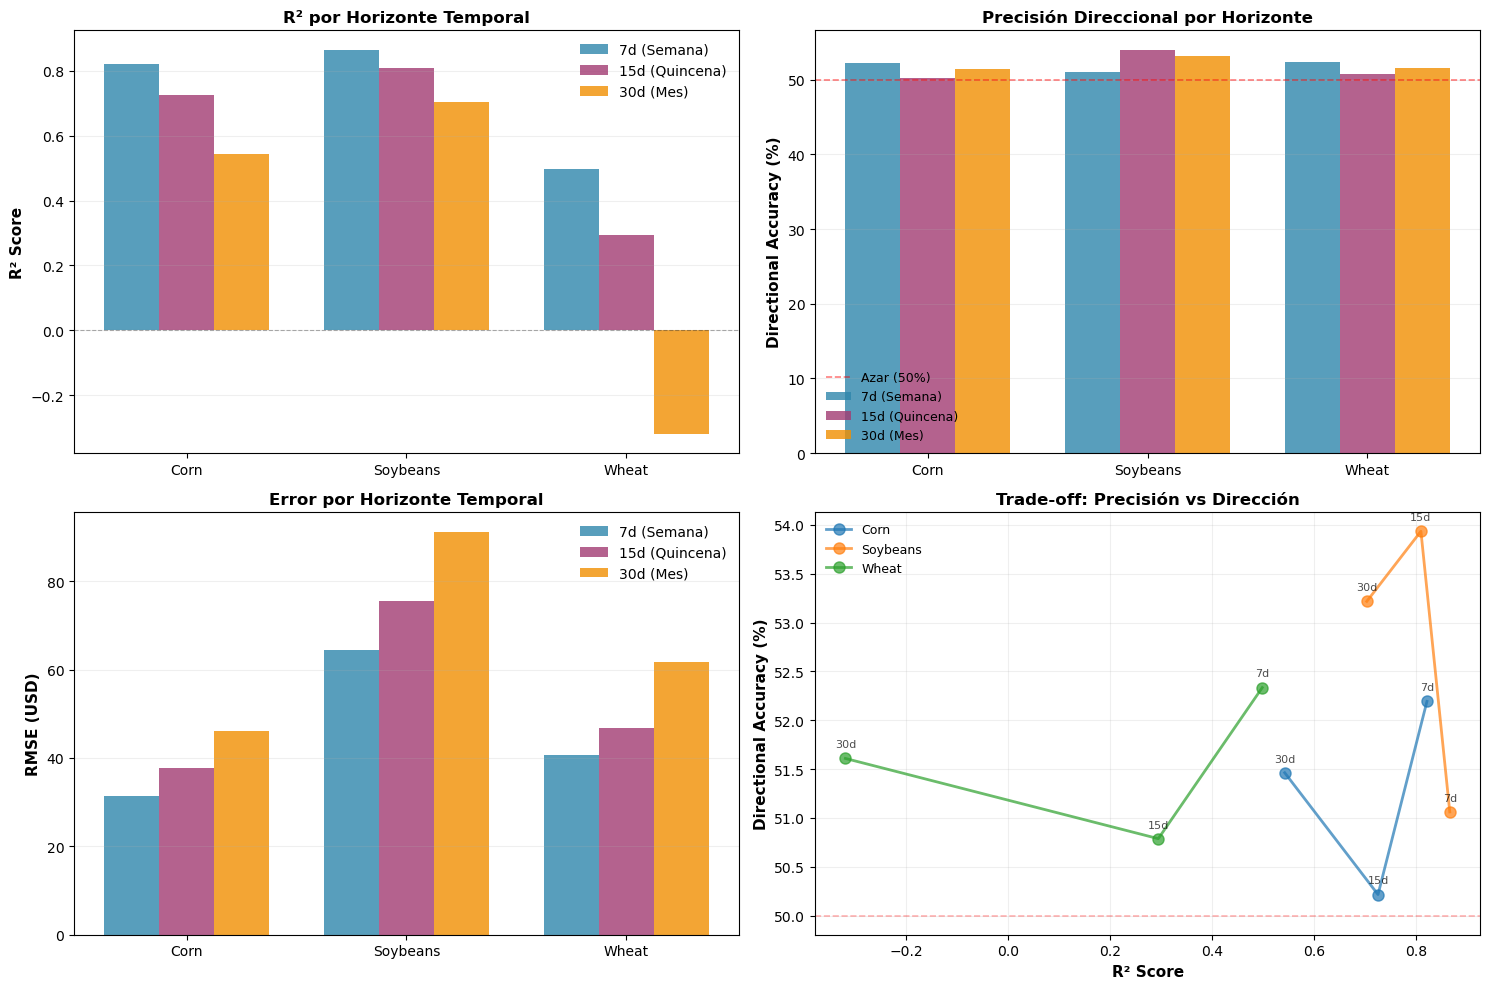


💾 Gráfico guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\reports\figures\lstm_multihorizonte_comparison.png


In [ ]:
if TENSORFLOW_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Preparar datos para gráficos
    metrics_to_plot = ['R²', 'Dir Acc', 'RMSE']
    colors_horizonte = {'7d (Semana)': '#2E86AB', '15d (Quincena)': '#A23B72', '30d (Mes)': '#F18F01'}
    
    # 1. R² por horizonte
    ax = axes[0, 0]
    for horizon_name in df_multihorizonte['Horizonte'].unique():
        subset = df_multihorizonte[df_multihorizonte['Horizonte'] == horizon_name]
        x = range(len(subset))
        ax.bar(
            [i + list(df_multihorizonte['Horizonte'].unique()).index(horizon_name) * 0.25 for i in x],
            subset['R²'],
            width=0.25,
            label=horizon_name,
            color=colors_horizonte[horizon_name],
            alpha=0.8
        )
    
    ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_title('R² por Horizonte Temporal', fontsize=12, fontweight='bold')
    ax.set_xticks([i + 0.25 for i in range(len(TARGET_COMMODITIES))])
    ax.set_xticklabels(TARGET_COMMODITIES, fontsize=10)
    ax.legend(frameon=False)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
    ax.grid(axis='y', alpha=0.2)
    
    # 2. Directional Accuracy por horizonte
    ax = axes[0, 1]
    for horizon_name in df_multihorizonte['Horizonte'].unique():
        subset = df_multihorizonte[df_multihorizonte['Horizonte'] == horizon_name]
        x = range(len(subset))
        ax.bar(
            [i + list(df_multihorizonte['Horizonte'].unique()).index(horizon_name) * 0.25 for i in x],
            subset['Dir Acc'] * 100,
            width=0.25,
            label=horizon_name,
            color=colors_horizonte[horizon_name],
            alpha=0.8
        )
    
    ax.set_ylabel('Directional Accuracy (%)', fontsize=11, fontweight='bold')
    ax.set_title('Precisión Direccional por Horizonte', fontsize=12, fontweight='bold')
    ax.set_xticks([i + 0.25 for i in range(len(TARGET_COMMODITIES))])
    ax.set_xticklabels(TARGET_COMMODITIES, fontsize=10)
    ax.axhline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.5, label='Azar (50%)')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    
    # 3. RMSE por horizonte
    ax = axes[1, 0]
    for horizon_name in df_multihorizonte['Horizonte'].unique():
        subset = df_multihorizonte[df_multihorizonte['Horizonte'] == horizon_name]
        x = range(len(subset))
        ax.bar(
            [i + list(df_multihorizonte['Horizonte'].unique()).index(horizon_name) * 0.25 for i in x],
            subset['RMSE'],
            width=0.25,
            label=horizon_name,
            color=colors_horizonte[horizon_name],
            alpha=0.8
        )
    
    ax.set_ylabel('RMSE (USD)', fontsize=11, fontweight='bold')
    ax.set_title('Error por Horizonte Temporal', fontsize=12, fontweight='bold')
    ax.set_xticks([i + 0.25 for i in range(len(TARGET_COMMODITIES))])
    ax.set_xticklabels(TARGET_COMMODITIES, fontsize=10)
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.2)
    
    # 4. Trade-off R² vs Dir Acc
    ax = axes[1, 1]
    for commodity in TARGET_COMMODITIES:
        subset = df_multihorizonte[df_multihorizonte['Commodity'] == commodity]
        ax.plot(
            subset['R²'],
            subset['Dir Acc'] * 100,
            marker='o',
            markersize=8,
            linewidth=2,
            label=commodity,
            alpha=0.7
        )
        
        # Anotar horizontes
        for idx, row in subset.iterrows():
            horizon_label = row['Horizonte'].split('d')[0] + 'd'
            ax.annotate(
                horizon_label,
                (row['R²'], row['Dir Acc'] * 100),
                textcoords="offset points",
                xytext=(0, 8),
                ha='center',
                fontsize=8,
                alpha=0.7
            )
    
    ax.set_xlabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Directional Accuracy (%)', fontsize=11, fontweight='bold')
    ax.set_title('Trade-off: Precisión vs Dirección', fontsize=12, fontweight='bold')
    ax.axhline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.3)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(alpha=0.2)
    
    plt.tight_layout()
    
    # Guardar en carpeta correcta
    figures_dir = BASE_DIR / 'reports' / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_dir / 'lstm_multihorizonte_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Gráfico guardado: {figures_dir / 'lstm_multihorizonte_comparison.png'}")

### Tabla Resumen: LSTM vs Tree Models

Comparación final entre los dos enfoques de modelado:

In [ ]:
# Cargar resultados de tree models (del notebook anterior)
tree_results_file = PROCESSED_DIR / 'baseline_models_results.json'

if tree_results_file.exists():
    import json
    with open(tree_results_file, 'r') as f:
        tree_results = json.load(f)
    
    # Crear tabla comparativa
    comparison_final = []
    
    # LSTM h=7 (comparable con tree models)
    for commodity in TARGET_COMMODITIES:
        if commodity in multihorizonte_results[7]:
            lstm_data = multihorizonte_results[7][commodity]
            comparison_final.append({
                'Modelo': 'LSTM (h=7)',
                'Commodity': commodity,
                'RMSE': lstm_data['rmse'],
                'R²': lstm_data['r2'],
                'Dir Acc (%)': lstm_data['dir_acc'] * 100,
                'Features': 'Univariado (solo precio)',
                'Tiempo (s)': lstm_data['time']
            })
    
    # Tree models del baseline
    for model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
        if model_name in tree_results:
            for commodity in TARGET_COMMODITIES:
                if commodity in tree_results[model_name]:
                    tree_data = tree_results[model_name][commodity]
                    comparison_final.append({
                        'Modelo': model_name,
                        'Commodity': commodity,
                        'RMSE': tree_data.get('rmse', tree_data.get('test_rmse', np.nan)),
                        'R²': tree_data.get('r2', tree_data.get('test_r2', np.nan)),
                        'Dir Acc (%)': tree_data.get('dir_acc', tree_data.get('test_dir_acc', np.nan)) * 100,
                        'Features': 'Multivariado (40+ features)',
                        'Tiempo (s)': tree_data.get('time', tree_data.get('train_time', np.nan))
                    })
    
    df_comparison_final = pd.DataFrame(comparison_final)
    
    # Ordenar y formatear
    df_comparison_final = df_comparison_final.sort_values(['Commodity', 'Dir Acc (%)'], ascending=[True, False])
    
    print("\n" + "="*90)
    print("COMPARACIÓN FINAL: LSTM vs Tree Models (horizonte 7 días)")
    print("="*90 + "\n")
    
    display(df_comparison_final.style.format({
        'RMSE': '{:.2f}',
        'R²': '{:.4f}',
        'Dir Acc (%)': '{:.2f}',
        'Tiempo (s)': '{:.1f}'
    }).background_gradient(subset=['Dir Acc (%)'], cmap='RdYlGn', vmin=45, vmax=70))
    
    # Estadísticas por modelo
    print("\n" + "-"*90)
    print("PROMEDIO POR MODELO:")
    print("-"*90 + "\n")
    
    stats_by_model = df_comparison_final.groupby('Modelo').agg({
        'RMSE': 'mean',
        'R²': 'mean',
        'Dir Acc (%)': 'mean',
        'Tiempo (s)': 'mean'
    }).round(2)
    
    display(stats_by_model.sort_values('Dir Acc (%)', ascending=False))
    
else:
    print("⚠️ Archivo baseline_models_results.json no encontrado")
    print("   Ejecutar notebook 3.1-3.3 primero para comparación completa")


COMPARACIÓN FINAL: LSTM vs Tree Models (horizonte 7 días)



,Modelo,Commodity,RMSE,R²,Dir Acc (%),Features,Tiempo (s)
0,LSTM (h=7),Corn,31.49,0.8208,52.19,Univariado (solo precio),142.6
1,LSTM (h=7),Soybeans,64.46,0.8655,51.06,Univariado (solo precio),135.8
2,LSTM (h=7),Wheat,40.64,0.4981,52.33,Univariado (solo precio),163.0



------------------------------------------------------------------------------------------
PROMEDIO POR MODELO:
------------------------------------------------------------------------------------------



,RMSE,R²,Dir Acc (%),Tiempo (s)
Modelo,,,,
LSTM (h=7),45.53,0.73,51.86,147.12


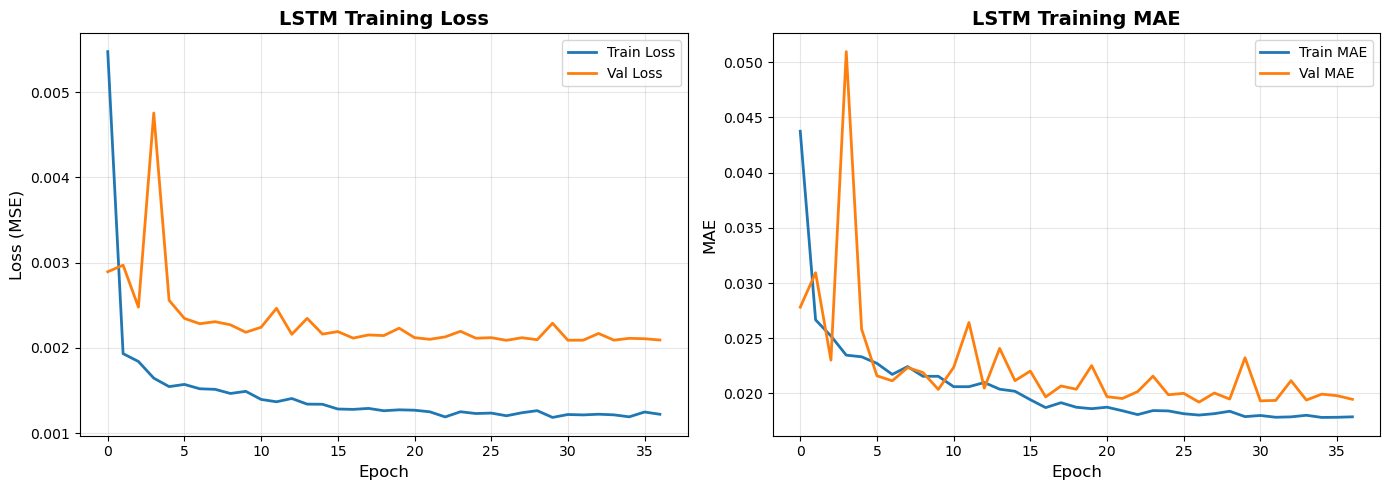

✓ Gráfico guardado: reports/figures/lstm_training_history.png


In [ ]:
if TENSORFLOW_AVAILABLE:
    # Plot loss curves (último commodity como ejemplo)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('LSTM Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # MAE
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('LSTM Training MAE', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'figures' / 'lstm_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico guardado: reports/figures/lstm_training_history.png")

---

## MODELO 2: Prophet

**Algoritmo:** Modelo aditivo de componentes (tendencia + estacionalidad + holidays).

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Donde:
- $g(t)$: Tendencia (lineal o logística)
- $s(t)$: Estacionalidad (Fourier series)
- $h(t)$: Efectos de holidays
- $\epsilon_t$: Error

**Ventajas:**
- Manejo automático de tendencias y estacionalidad
- Robusto a datos faltantes
- Interpretable (descompone componentes)
- No requiere normalización

**Configuración:**
- `changepoint_prior_scale`: Flexibilidad de tendencia (0.05 default)
- `seasonality_prior_scale`: Fuerza de estacionalidad (10 default)
- `yearly_seasonality`, `weekly_seasonality`: Estacionalidades a incluir

In [ ]:
if not PROPHET_AVAILABLE:
    print("⚠ Saltando Prophet - Prophet no disponible")
else:
    prophet_models = {}
    prophet_results = {}
    
    print(f"\n{'='*80}")
    print(f"PROPHET (Facebook Time Series Forecasting)")
    print(f"{'='*80}")
    
    with tqdm(TARGET_COMMODITIES, desc="Prophet Models", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"Prophet: {commodity}")
            start_time = perf_counter()
            
            print(f"\n--- {commodity} ---")
        
        # 1. Preparar datos en formato Prophet (ds, y)
        train_prophet = train_df[['date', commodity]].copy()
        train_prophet.columns = ['ds', 'y']
        train_prophet = train_prophet.dropna()
        
        test_prophet = test_df[['date', commodity]].copy()
        test_prophet.columns = ['ds', 'y']
        test_prophet = test_prophet.dropna()
        
        print(f"  Train: {len(train_prophet):,} obs")
        print(f"  Test: {len(test_prophet):,} obs")
        
        # 2. Configurar y entrenar modelo
        model = Prophet(
            changepoint_prior_scale=0.05,  # Flexibilidad de tendencia
            seasonality_prior_scale=10,    # Fuerza de estacionalidad
            yearly_seasonality=True,       # Estacionalidad anual
            weekly_seasonality=False,      # No estacionalidad semanal (datos diarios)
            daily_seasonality=False        # No estacionalidad diaria
        )
        
        # Agregar estacionalidad mensual
        model.add_seasonality(
            name='monthly',
            period=30.5,
            fourier_order=5
        )
        
        print(f"\n  Entrenando Prophet...")
        model.fit(train_prophet)
        prophet_models[commodity] = model
        
        # 3. Predecir en train
        train_forecast = model.predict(train_prophet[['ds']])
        y_train = train_prophet['y'].values
        y_train_pred = train_forecast['yhat'].values
        
        # 4. Predecir en test
        test_forecast = model.predict(test_prophet[['ds']])
        y_test = test_prophet['y'].values
        y_test_pred = test_forecast['yhat'].values
        
        # 5. Métricas
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Directional accuracy
        y_train_direction = np.sign(np.diff(y_train))
        y_train_pred_direction = np.sign(np.diff(y_train_pred))
        train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
        
        y_test_direction = np.sign(np.diff(y_test))
        y_test_pred_direction = np.sign(np.diff(y_test_pred))
        test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        prophet_results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
        
        # Imprimir resultados
        elapsed = perf_counter() - start_time
        print(f"\n  Resultados:")
        print(f"    Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
        print(f"    Train R²:   {train_r2:.4f} | Test R²:   {test_r2:.4f}")
        print(f"    Test Dir Acc: {test_dir_acc:.2%}")
        print(f"    Overfitting gap: {train_r2 - test_r2:.4f}")
        print(f"    Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_R2': f"{test_r2:.3f}", 'Time': f"{elapsed:.0f}s"})
    
    print(f"\n{'='*80}")

⚠ Saltando Prophet - Prophet no disponible


### Visualización: Prophet Components

In [ ]:
if PROPHET_AVAILABLE:
    # Plot componentes de Prophet (último commodity como ejemplo)
    fig = model.plot_components(test_forecast)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'reports' / 'figures' / 'prophet_components.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Gráfico guardado: reports/figures/prophet_components.png")

---

## 3. Comparación: Time Series vs Tree Models vs Baseline

In [ ]:
# DEBUG: Verificar lstm_results
print("lstm_results:")
for commodity, results in lstm_results.items():
    print(f"\n{commodity}:")
    print(f"  Test RMSE: {results['test_rmse']:.4f}")
    print(f"  Test R²: {results['test_r2']:.4f}")
    print(f"  Test Dir Acc: {results['test_dir_acc']:.2%}")

lstm_results:

Corn:
  Test RMSE: 29.6968
  Test R²: 0.8485
  Test Dir Acc: 46.70%

Soybeans:
  Test RMSE: 61.3463
  Test R²: 0.8810
  Test Dir Acc: 44.88%

Wheat:
  Test RMSE: 32.3449
  Test R²: 0.7064
  Test Dir Acc: 45.58%


In [ ]:
# Cargar resultados anteriores
baseline_file = PROCESSED_DIR / 'baseline_models_results.json'
tree_file = PROCESSED_DIR / 'tree_models_results.json'

comparison_data = []

# Agregar baseline results
if baseline_file.exists():
    with open(baseline_file, 'r') as f:
        baseline_data = json.load(f)
    comparison_data.extend(baseline_data['results'])

# Agregar tree results
if tree_file.exists():
    with open(tree_file, 'r') as f:
        tree_data = json.load(f)
    comparison_data.extend(tree_data['results'])

# Agregar LSTM results
if TENSORFLOW_AVAILABLE:
    for commodity in TARGET_COMMODITIES:
        if commodity in lstm_results:
            r = lstm_results[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': 'LSTM',
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

# Agregar Prophet results
if PROPHET_AVAILABLE:
    for commodity in TARGET_COMMODITIES:
        if commodity in prophet_results:
            r = prophet_results[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': 'Prophet',
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN: TIME SERIES vs TREE vs BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN: TIME SERIES vs TREE vs BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
33,LSTM,29.696775,0.848508,0.467041,0.103046
2,Lasso,32.008394,0.851097,0.544098,0.087402
14,Lasso,32.008394,0.851097,0.544098,0.087402
0,Linear Regression,32.103000,0.850216,0.540027,0.089283
12,Linear Regression,32.103000,0.850216,0.540027,0.089283
1,Ridge,32.439980,0.847055,0.537313,0.092338
13,Ridge,32.439980,0.847055,0.537313,0.092338
3,Elastic Net,33.710702,0.834838,0.530529,0.103243
15,Elastic Net,33.710702,0.834838,0.530529,0.103243
26,LightGBM,48.742030,0.654712,0.510176,0.248085



✓ Mejor modelo: LSTM (RMSE: 29.6968)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
34,LSTM,61.346305,0.881026,0.448808,0.075433
6,Lasso,64.345495,0.878580,0.541384,0.069215
18,Lasso,64.345495,0.878580,0.541384,0.069215
28,XGBoost,65.170362,0.875447,0.530529,0.081993
29,LightGBM,72.556317,0.845616,0.504749,0.116260
7,Elastic Net,76.660774,0.827655,0.544098,0.120708
19,Elastic Net,76.660774,0.827655,0.544098,0.120708
5,Ridge,77.332392,0.824622,0.548168,0.124067
17,Ridge,77.332392,0.824622,0.548168,0.124067
4,Linear Regression,79.077019,0.816619,0.546811,0.132132



✓ Mejor modelo: LSTM (RMSE: 61.3463)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
35,LSTM,32.344869,0.706446,0.455820,0.238792
10,Lasso,35.556155,0.687440,0.526459,0.231661
22,Lasso,35.556155,0.687440,0.526459,0.231661
9,Ridge,35.946250,0.680544,0.518318,0.238699
21,Ridge,35.946250,0.680544,0.518318,0.238699
32,LightGBM,37.818400,0.646401,0.535957,0.242561
8,Linear Regression,39.469936,0.614844,0.541384,0.306691
20,Linear Regression,39.469936,0.614844,0.541384,0.306691
31,XGBoost,39.496012,0.614334,0.523745,0.329245
11,Elastic Net,40.713669,0.590188,0.518318,0.324226



✓ Mejor modelo: LSTM (RMSE: 32.3449)



### Visualización: Comparación Completa

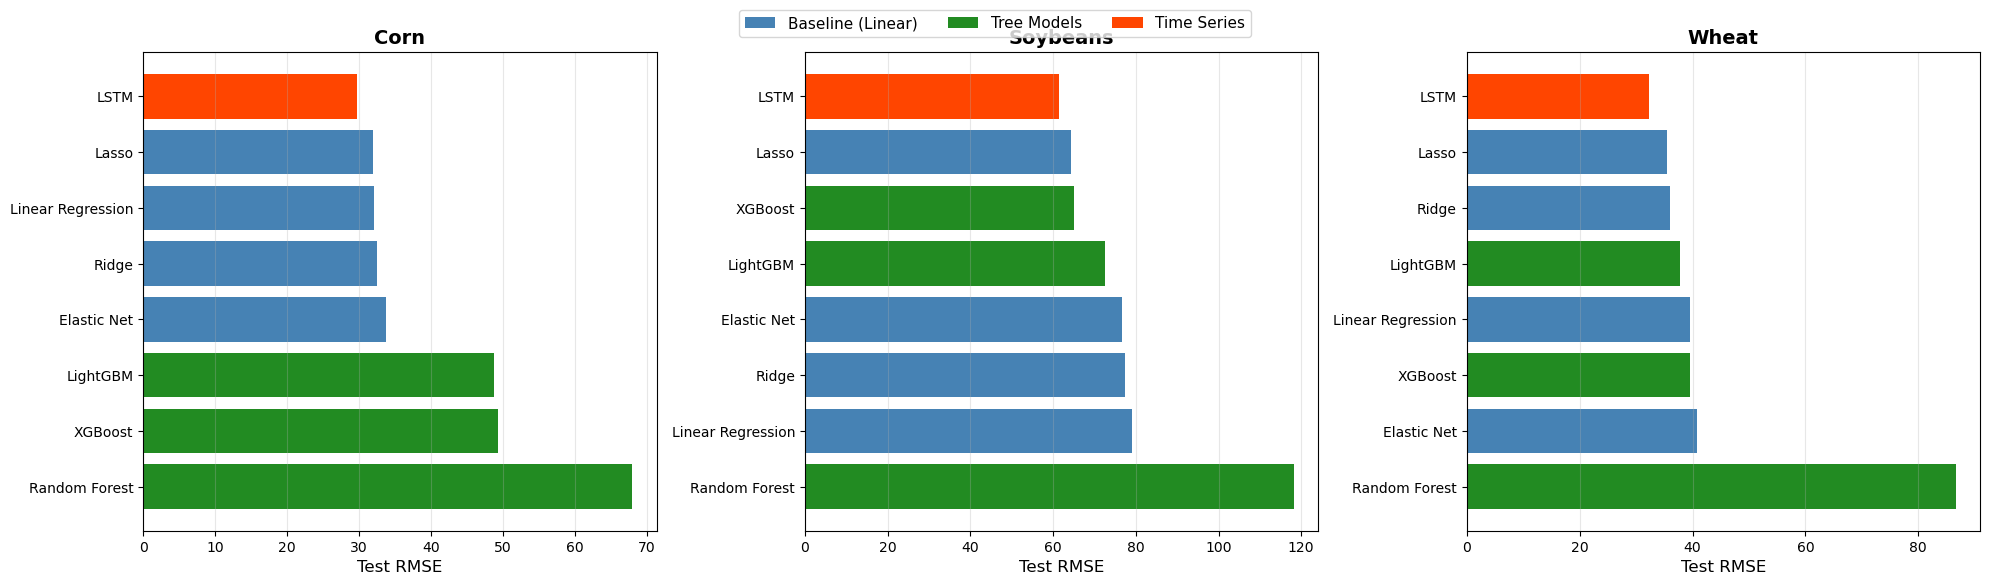

✓ Gráfico guardado: reports/figures/all_models_comparison.png


In [ ]:
# Plot comparativo de todos los modelos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    
    ax = axes[idx]
    
    # Colorear por tipo de modelo
    colors = []
    for model in commodity_results['Model']:
        if model in ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net']:
            colors.append('steelblue')
        elif model in ['Random Forest', 'XGBoost', 'LightGBM']:
            colors.append('forestgreen')
        else:  # LSTM, Prophet
            colors.append('orangered')
    
    ax.barh(commodity_results['Model'], commodity_results['Test RMSE'], color=colors)
    ax.set_xlabel('Test RMSE', fontsize=12)
    ax.set_title(f'{commodity}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Baseline (Linear)'),
    Patch(facecolor='forestgreen', label='Tree Models'),
    Patch(facecolor='orangered', label='Time Series')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/all_models_comparison.png")

---

## 4. Guardar Modelos y Resultados

In [ ]:
import pickle

# Guardar modelos time series
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

# LSTM models
if TENSORFLOW_AVAILABLE:
    for commodity, model in lstm_models.items():
        model_file = models_dir / f'lstm_{commodity.lower()}.h5'
        model.save(model_file)
        print(f"✓ LSTM guardado: {model_file}")
    
    # Guardar scalers
    scalers_file = models_dir / 'lstm_scalers.pkl'
    with open(scalers_file, 'wb') as f:
        pickle.dump(lstm_scalers, f)
    print(f"✓ Scalers guardados: {scalers_file}")

# Prophet models
if PROPHET_AVAILABLE:
    prophet_file = models_dir / 'prophet_models.pkl'
    with open(prophet_file, 'wb') as f:
        pickle.dump(prophet_models, f)
    print(f"✓ Prophet guardado: {prophet_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': [],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'config': {}
}

if TENSORFLOW_AVAILABLE:
    results_summary['models'].append('LSTM')
    results_summary['config']['lstm'] = {
        'sequence_length': SEQUENCE_LENGTH,
        'lstm_units': LSTM_UNITS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS
    }

if PROPHET_AVAILABLE:
    results_summary['models'].append('Prophet')
    results_summary['config']['prophet'] = {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 10,
        'yearly_seasonality': True,
        'monthly_seasonality': True
    }

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'time_series_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✓ Resultados guardados: {results_file}")

2025-11-10 23:01:51 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 23:01:51 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 23:01:51 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-11-10 23:01:51 - absl - WARNING - Y

✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_corn.h5
✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_soybeans.h5
✓ LSTM guardado: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_wheat.h5
✓ Scalers guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\lstm_scalers.pkl

✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\time_series_models_results.json
